# In-class Assignment 8.1

**Week 8 Monday**

#### &#x2705; Stephanie, Alex, Cy

---

## Part 1: Getting Familiar with a Data Set

In this unit, we will figure out how to use a data set as a resource for building a computational model.

You can find the data set we'll be using in `~/hub_data_share/data/MuRun2010B.csv`.

&#9989; Load the data set into your notebook using the pandas function `read_csv`.

Tips:
- Use documentation to learn about the `read_csv` function.
- Open the data file in the JupyterHub interface to see what it contains.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('MuRun2010B.csv', skiprows=5)

&#9989; View the data set in your notebook using pandas functions like `head` and `describe`. Discuss and document things you notice about the overall data set.

In [2]:
df.head()

,Run,Event,Type1,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,Type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2
0,146436,90830792,G,19.17120,3.817130,9.04323,-16.46730,9.81583,-1.289420,1.171390,1,T,5.43984,-0.362592,2.626990,-4.748490,2.65189,-1.345870,1.707960,1
1,146436,90862225,G,12.94350,5.125790,-3.98369,-11.19730,6.49180,-1.313350,-0.660674,-1,G,11.86360,4.789840,-6.262220,-8.864340,7.88403,-0.966622,-0.917841,1
2,146436,90644850,G,12.39990,-0.849742,9.40110,8.04015,9.43943,0.772580,1.660940,1,G,8.55532,-4.851550,6.976960,-0.983229,8.49797,-0.115445,2.178410,-1
3,146436,90678594,G,17.81320,-1.959590,2.80531,17.48110,3.42195,2.333500,2.180530,1,G,9.42174,4.365230,0.168017,8.347130,4.36846,1.403000,0.038471,1
4,146436,90686690,G,7.95664,7.097000,-1.31646,3.34613,7.21806,0.448399,-0.183411,1,T,5.44467,-1.341760,1.386470,5.090250,1.92941,1.697380,2.339810,-1


In [3]:
df.describe()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,147955.518910,3.600568e+08,17.665188,-0.061691,-0.197864,-0.834725,7.521848,-0.116067,-0.039216,0.022640,9.200238,-0.012066,0.196614,0.804217,4.968886,0.106296,0.029453,-0.001960
std,1009.016673,3.425911e+08,22.474517,7.186708,7.229930,26.692576,6.883665,1.511516,1.824423,0.999749,20.470750,7.641683,6.524565,20.050790,8.735779,1.404998,1.814451,1.000003
min,146428.000000,4.982000e+03,2.703340,-221.622000,-313.942000,-2158.810000,1.001750,-2.611640,-3.141570,-1.000000,2.506870,-1501.300000,-105.613000,-1232.880000,0.563436,-2.615690,-3.141590,-1.000000
25%,146807.000000,1.047934e+08,8.446880,-3.599162,-3.645665,-11.030350,3.927078,-1.527967,-1.626850,-1.000000,4.794437,-2.239950,-2.124545,-4.230577,2.048237,-1.099540,-1.538377,-1.000000
50%,148058.000000,2.547149e+08,12.585600,-0.060634,-0.156428,-2.082375,5.615290,-0.277083,-0.063298,1.000000,6.641075,-0.014198,0.056748,0.956394,4.076730,0.168187,0.044331,-1.000000
75%,148864.000000,4.972217e+08,20.417300,3.473032,3.411145,9.631530,9.397340,1.383780,1.530945,1.000000,10.052200,2.260153,2.353935,5.379317,5.763505,1.393425,1.611265,1.000000
max,149294.000000,1.776807e+09,3384.430000,593.661000,385.344000,3309.590000,707.759000,2.566250,3.141570,1.000000,4346.030000,750.348000,1003.490000,4251.780000,1805.790000,2.711330,3.141560,1.000000


---

## Part describetering and Organizing the Data

Collider experiments are designed to detect decay products from high-energy collision. The Large Hadron Collider sends protons, neutrons, and isotopes flying at each other at top speeds. The resulting collisions and decays are then detected as the events you see in the data set.

&#9989; Discuss with your group, which events do you think could give you insight to a particle that decayed into muons?

*Hint: Can you use conservation laws to narrow your focus on specific events?*

Graph the data and find the peak(s) which is where there is more statistical certainty that the particles are decaying into muons.

&#9989; Filter the data set according to the events that you and your group want to focus on.

In [6]:
# filter for events we want to focus on

same_charge = df[df['Q1'] == df['Q2']]
different_charge = df[df['Q1'] != df['Q2']]
# sameCharge.loc[:, ['Q1', 'Q2']].head()

---

## Part 3: Visualizing the Data

&#9989; How can you visualize the events that you want to focus on? Discuss with your group and create visualization(s) that can help you gain insight to the particles that can be identified from the data set.

In [13]:
# compute invariant mass
elab_new = same_charge['E1'] + same_charge['E2']
px_new = same_charge['px1 '] + same_charge['px2']
py_new = same_charge['py1'] + same_charge['py2']
pz_new = same_charge['pz1'] + same_charge['pz2']

M_new = (elab_new**2 - (px_new**2 + py_new**2 + pz_new**2))**0.5

# display new columns
same_charge.head()
M_new.head()

0     2.732339
3     7.747046
11    8.478128
12    6.790807
13    9.973186
dtype: float64

In [20]:
same_charge.insert(0, 'M_new', pd.Series(M_new))
same_charge.head()

,M_new,M,Run,Event,Type1,E1,px1,py1,pz1,pt1,...,Q1,Type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2
0,2.732339,2.732339,146436,90830792,G,19.17120,3.81713,9.043230,-16.46730,9.81583,...,1,T,5.43984,-0.362592,2.626990,-4.74849,2.65189,-1.345870,1.707960,1
3,7.747046,7.747046,146436,90678594,G,17.81320,-1.95959,2.805310,17.48110,3.42195,...,1,G,9.42174,4.365230,0.168017,8.34713,4.36846,1.403000,0.038471,1
11,8.478128,8.478128,146436,90733245,G,5.94088,1.89526,0.200522,5.62590,1.90584,...,1,T,5.51003,-4.810740,-2.430500,1.13959,5.38986,0.209888,-2.673780,1
12,6.790807,6.790807,146436,90779622,G,18.37970,2.24914,3.198480,17.95860,3.91010,...,-1,G,8.11221,-3.185100,2.778830,6.92316,4.22691,1.268890,2.424210,-1
13,9.973186,9.973186,146436,90788478,G,13.29960,1.33269,13.034200,-2.28086,13.10210,...,1,T,6.65812,0.323117,1.827180,-6.39346,1.85553,-1.950670,1.395770,1


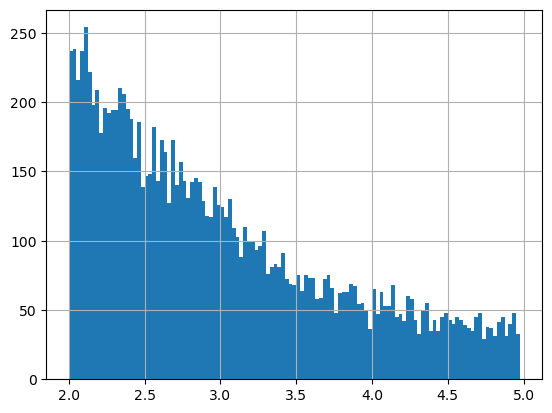

In [22]:
import matplotlib.pyplot as plt
import numpy as np

b = np.arange(2, 5, 0.025)
plt.hist(same_charge['M_new'], bins = b)
plt.grid(True)
plt.show()